# 2. Machine Learning for Regression

In [38]:
import pandas as pd
import numpy as np

## 2.2 Data preparation

In [22]:
df = pd.read_csv("data/car_data/data.csv")

In [23]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [24]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [25]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## 2.3 Data Exploration

In [26]:
for col in df.columns:
    print(col, df[col].nunique())
    print(df[col].unique()[:5])
    print()

make 48
<StringArray>
['BMW', 'Audi', 'FIAT', 'Mercedes-Benz', 'Chrysler']
Length: 5, dtype: str

model 915
<StringArray>
['1 Series M', '1 Series', '100', '124 Spider', '190-Class']
Length: 5, dtype: str

year 28
[2011 2012 2013 1992 1993]

engine_fuel_type 10
<StringArray>
[   'premium unleaded (required)',               'regular unleaded',
 'premium unleaded (recommended)',       'flex-fuel (unleaded/E85)',
                         'diesel']
Length: 5, dtype: str

engine_hp 356
[335. 300. 230. 320. 172.]

engine_cylinders 9
[ 6.  4.  5.  8. 12.]

transmission_type 5
<StringArray>
['MANUAL', 'AUTOMATIC', 'AUTOMATED_MANUAL', 'DIRECT_DRIVE', 'UNKNOWN']
Length: 5, dtype: str

driven_wheels 4
<StringArray>
['rear wheel drive', 'front wheel drive', 'all wheel drive',
 'four wheel drive']
Length: 4, dtype: str

number_of_doors 3
[ 2.  4.  3. nan]

market_category 71
<StringArray>
['Factory Tuner,Luxury,High-Performance',
                    'Luxury,Performance',
               'Luxury,High

In [14]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [27]:
df.dtypes == "str"

make                  True
model                 True
year                 False
engine_fuel_type      True
engine_hp            False
engine_cylinders     False
transmission_type     True
driven_wheels         True
number_of_doors      False
market_category       True
vehicle_size          True
vehicle_style         True
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [28]:
str_col = df.dtypes[df.dtypes=="str"]

In [29]:
str_col

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [30]:
for column in str_col.index:
    df[column] = df[column].str.lower().str.replace(" ", "_")

In [31]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

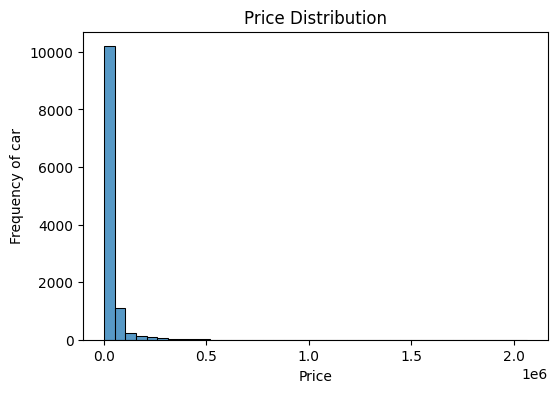

In [34]:
plt.figure(figsize=(6,4))
sns.histplot(df.msrp, bins=40)
plt.xlabel("Price")
plt.ylabel("Frequency of car")
plt.title("Price Distribution")
plt.show()

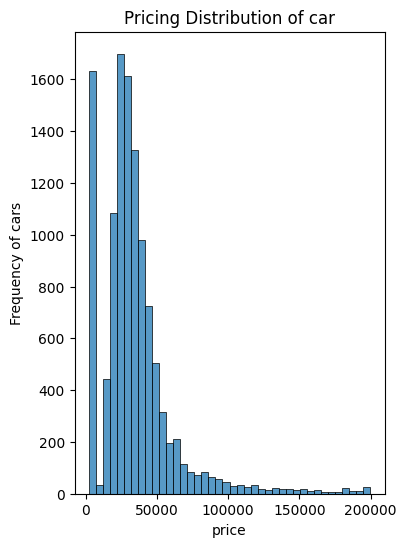

In [35]:
plt.figure(figsize=(4,6))
sns.histplot(df.msrp[df.msrp <= 200000], bins=40)
plt.xlabel("price")
plt.ylabel("Frequency of cars")
plt.title("Pricing Distribution of car")
plt.show()

In [36]:
df.msrp = np.log(df.msrp)

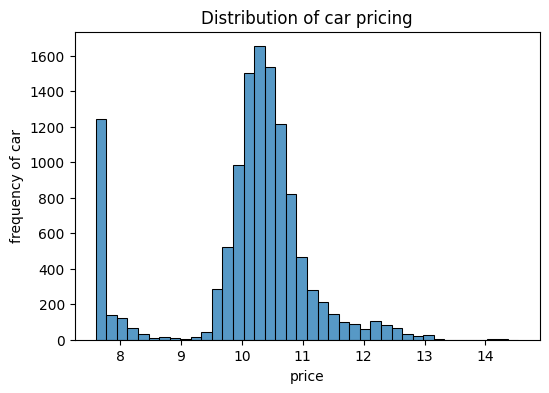

In [37]:
plt.figure(figsize=(6,4))
sns.histplot(df.msrp, bins=40)
plt.xlabel("price")
plt.ylabel("frequency of car")
plt.title("Distribution of car pricing")
plt.show()

In [ ]:
df.dtypes[df.dtypes == "int64"]

,0
year,int64
highway_mpg,int64
city_mpg,int64
popularity,int64


## 2.4 Setting up the validation framework

In [40]:
n = len(df)
n

11914

Splitting the data into 60-20-20

In [46]:
n_train = int(n*0.6)
n_val = int(n*0.2)
n_test = int(n*0.2)

print(n_train, n_val, n_test)

7148 2382 2382


In [47]:
print(n_train+n_val+n_test, n)

11912 11914


If I use this directly to split the data, some data will be lost due to the round off. So let's slicing for val and test set. The remaining will go to test

In [49]:
x_val = df[:n_val]
x_test = df[n_val: n_val+n_test]
x_train = df[n_val+n_test:]

print(x_train.shape, x_val.shape, x_test.shape)

(7150, 16) (2382, 16) (2382, 16)


let's verify

In [50]:
print(x_train.shape[0]+x_val.shape[0]+x_test.shape[0], n)

11914 11914


In [51]:
x_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
4764,ford,flex,2016,regular_unleaded,287.0,6.0,automatic,front_wheel_drive,4.0,"crossover,performance",large,wagon,23,16,5657,10.540064
4765,ford,flex,2017,premium_unleaded_(recommended),365.0,6.0,automatic,all_wheel_drive,4.0,crossover,large,wagon,21,15,5657,10.669653
4766,ford,flex,2017,regular_unleaded,287.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",large,wagon,22,16,5657,10.601125
4767,ford,flex,2017,regular_unleaded,287.0,6.0,automatic,front_wheel_drive,4.0,"crossover,performance",large,wagon,23,16,5657,10.396047
4768,ford,flex,2017,regular_unleaded,287.0,6.0,automatic,front_wheel_drive,4.0,"crossover,performance",large,wagon,23,16,5657,10.551376


In [52]:
x_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,10.739327
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,10.612754
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,10.500949
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,10.290449
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,10.448715


As we can observe the is not shuffled, so we need to shuffle it

In [64]:
np.random.seed(1)
idx = np.arange(n)
np.random.shuffle(idx)

df_val = df.iloc[idx[:n_val]]
df_test = df.iloc[idx[n_val:n_val+n_test]]
df_train = df.iloc[idx[n_val+n_test:]]

In [65]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
10931,toyota,tundra,2015,regular_unleaded,381.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,18,13,2031,10.712750
9160,dodge,shadow,1993,regular_unleaded,100.0,4.0,manual,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,29,22,1851,7.600902
3840,hyundai,elantra_gt,2016,regular_unleaded,173.0,4.0,manual,front_wheel_drive,4.0,"hatchback,performance",compact,4dr_hatchback,33,24,1439,9.841612
5780,mitsubishi,i-miev,2017,electric,66.0,NaN,direct_drive,rear_wheel_drive,4.0,hatchback,compact,4dr_hatchback,102,121,436,10.043032
8637,audi,rs_5,2014,premium_unleaded_(required),450.0,8.0,automated_manual,all_wheel_drive,2.0,"factory_tuner,luxury,high-performance",midsize,convertible,22,16,3105,11.263181


In [66]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
4257,lotus,evora_400,2017,premium_unleaded_(required),400.0,6.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,39,21,613,11.428456
11151,aston_martin,v8_vantage,2014,premium_unleaded_(required),420.0,8.0,automated_manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,convertible,21,14,259,11.827006
5262,hyundai,genesis,2015,regular_unleaded,311.0,6.0,automatic,rear_wheel_drive,4.0,"luxury,performance",large,sedan,29,18,1439,10.545341
8965,suzuki,samurai,1993,regular_unleaded,66.0,4.0,manual,four_wheel_drive,2.0,NaN,compact,convertible_suv,26,24,481,7.600902
7380,mitsubishi,outlander,2015,regular_unleaded,166.0,4.0,automatic,all_wheel_drive,4.0,crossover,midsize,4dr_suv,29,24,436,10.173324


Now we have the dataset split and the distribution of the data through out the set is normal, Let's reset the index and have y sets

In [67]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [68]:
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [71]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,toyota,tundra,2015,regular_unleaded,381.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,18,13,2031,10.712750
1,dodge,shadow,1993,regular_unleaded,100.0,4.0,manual,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,29,22,1851,7.600902
2,hyundai,elantra_gt,2016,regular_unleaded,173.0,4.0,manual,front_wheel_drive,4.0,"hatchback,performance",compact,4dr_hatchback,33,24,1439,9.841612
3,mitsubishi,i-miev,2017,electric,66.0,NaN,direct_drive,rear_wheel_drive,4.0,hatchback,compact,4dr_hatchback,102,121,436,10.043032
4,audi,rs_5,2014,premium_unleaded_(required),450.0,8.0,automated_manual,all_wheel_drive,2.0,"factory_tuner,luxury,high-performance",midsize,convertible,22,16,3105,11.263181


In [75]:
y_train = df_train.msrp.values
y_val = df_val.msrp.values
y_test = df_test.msrp.values

In [79]:
df_train.drop(columns=["msrp"], inplace=True)

In [81]:
df_val.drop(columns=["msrp"], inplace=True)
df_test.drop(columns=["msrp"], inplace=True)

In [82]:
len(y_train), len(y_val), len(y_test)

(7150, 2382, 2382)

## 2.5 Linear Regression

In [83]:
df_train.iloc[10]

make                         chevrolet
model                   malibu_limited
year                              2016
engine_fuel_type      regular_unleaded
engine_hp                        197.0
engine_cylinders                   4.0
transmission_type            automatic
driven_wheels        front_wheel_drive
number_of_doors                    4.0
market_category                    NaN
vehicle_size                   midsize
vehicle_style                    sedan
highway_mpg                         34
city_mpg                            24
popularity                        1385
Name: 10, dtype: object

In [86]:
xi = [197, 34, 24, 1385]
w0 = 4.2
wj = [0.1, 0.01, 0.01, 0.001]

n = len(xi)
pred = 4.2

for j in range(n):
    pred += xi[j] * wj[j]

pred

25.865000000000002

In [88]:
def linear_regression(xi, wj, w0):
    n = len(xi)
    pred = w0
    
    for j in range(n):
        pred += xi[j] * wj[j]
    
    return pred

In [90]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

y_dummy = linear_regression(xi, w, w0)

In [91]:
np.exp(y_dummy)

np.float64(222348.2221101062)

## 2.6 Linear Regression vector form